In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(
    "/Users/pater32/Documents/GitHub/sage/GWRecoil/output/sage-plot"
)

import sage_loader
from sage_loader import get_params, load_snapshot, load_all_snapshots
from snapshot_redshift_mapper import SnapshotRedshiftMapper as z_mapper
print(sage_loader.__file__)
dir(sage_loader)

/Users/pater32/Documents/GitHub/sage/GWRecoil/output/sage-plot/sage_loader.py


['DummyArgs',
 'SnapshotRedshiftMapper',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'get_params',
 'importlib',
 'load_all_snapshots',
 'load_snapshot',
 'os',
 'path',
 'sage_plot',
 'spec']

In [2]:
param_file = "/Users/pater32/Documents/GitHub/sage/GWRecoil/input/tng50.par"

params = get_params(param_file)
galaxies, volume, metadata = load_snapshot(param_file, 99)
data = load_all_snapshots(param_file)

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z0.000
Input files contain: 15618 trees, 22282 galaxies.
Reading 22282 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z0.000_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHu

In [3]:
print(load_snapshot(param_file, 0))

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050_0
(rec.array([],
          dtype={'names': ['SnapNum', 'Type', 'GalaxyIndex', 'CentralGalaxyIndex', 'SAGEHaloIndex', 'SAGETreeIndex', 'SimulationHaloIndex', 'mergeType', 'mergeIntoID', 'mergeIntoSnapNum', 'dT', 'Pos', 'Vel', 'Spin', 'Len', 'Mvir', 'CentralMvir', 'Rvir', 'Vvir', 'Vmax', 'VelDisp', 'ColdGas', 'StellarMass', 'BulgeMass', 'HotGas', 'EjectedMass', 'BlackHoleMass', 'IntraClusterStars', 'NSC', 'MetalsColdGas', 'MetalsStellarMass', 'MetalsBulgeMass', 'MetalsHotGas', 'MetalsEjectedMass', 'MetalsIntraClusterStars', 'SfrDisk', 'SfrBulge', 'SfrDiskZ', 'SfrBulgeZ', 'DiskRadius', 'Co

(5.0, 9.0)

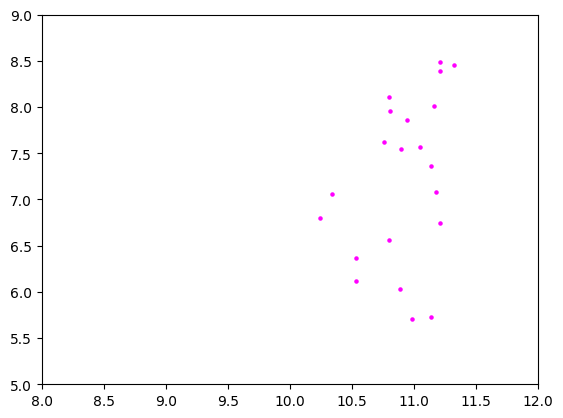

In [4]:
## RECREATE STELLARMASS - BHMASS PLOT 

w = (galaxies.StellarMass > 0) & (galaxies.BlackHoleMass > 0)
m = w & (galaxies.BHmergeCount > 0)
r = w & (galaxies.BHrefillCount > 0) & (galaxies.BHejectFlag == 0)

hubble_h = metadata['hubble_h']

stellar_mass = np.log10(galaxies.StellarMass[w] * 1e10 / hubble_h)
bh_mass = np.log10(galaxies.BlackHoleMass[w] * 1e10 / hubble_h)

stellar_mass_merge = np.log10(galaxies.StellarMass[m] * 1e10 / hubble_h)
bh_mass_merge = np.log10(galaxies.BlackHoleMass[m] * 1e10 / hubble_h)

stellar_mass_refill = np.log10(galaxies.StellarMass[r] * 1e10 / hubble_h)
bh_mass_refill = np.log10(galaxies.BlackHoleMass[r] * 1e10 / hubble_h)


# plt.scatter(
#     stellar_mass,
#     bh_mass,
#     marker = 'o',
#     color = 'grey',
#     s=1,
#     alpha = 0.2
# )

# plt.scatter(
#     stellar_mass_merge,
#     bh_mass_merge,
#     marker = 'o',
#     color = 'cornflowerblue',
#     s=5
# )

plt.scatter(
    stellar_mass_refill,
    bh_mass_refill,
    marker = 'o',
    color = 'magenta',
    s=5
)

plt.xlim(8.0, 12.0)
plt.ylim(5, 9)

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z0.000
Input files contain: 15618 trees, 22282 galaxies.
Reading 22282 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z0.000_0
[          2202           1119     1000000000     4000000000
     7000000000    15000000000  2235000000057  4464000000000
  4472000000000  4476000000000  4520000000000  6698000000000
  6708000000000  8925000000933  8929000000000  8931000000000
  8936000000000  8944000000000 11158000000000 13387000000561
 13389000000000 13392000000000]
Amount of BHs ejected for galaxy 2202 : 1
Amount of BHs ejected for galaxy 1119 : 1
Amount of BHs ejected for galaxy 1000000000 : 1
Amount of BHs ejected for galaxy 4000000000 : 2
Amount of BHs ejected for galaxy 7000000000 : 1
Amount of BHs ejecte

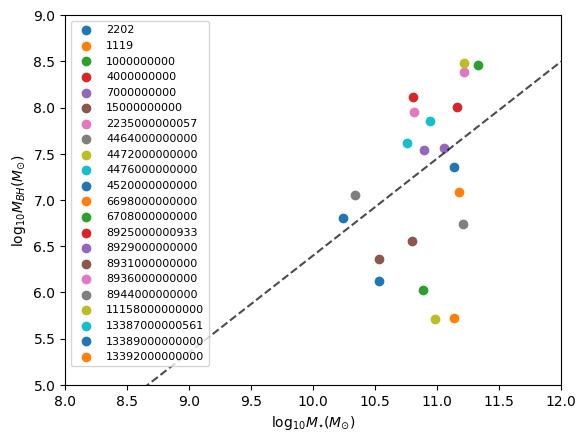

In [6]:
galaxies, volume, metadata = load_snapshot(param_file, 99)

w = (galaxies.StellarMass > 0) & (galaxies.BlackHoleMass > 0)
r = w & (galaxies.BHrefillCount > 0) & (galaxies.BHejectFlag == 0)

gal_ids_refilled = galaxies.GalaxyIndex[r]
print(gal_ids_refilled)

gal_id = 1119


for i in range(len(galaxies)):
    for gal_id in gal_ids_refilled:
        if galaxies.GalaxyIndex[i] == gal_id:
            stellar_mass = np.log10(galaxies.StellarMass[i] * 1e10 / hubble_h)
            bh_mass = np.log10(galaxies.BlackHoleMass[i] * 1e10 / hubble_h)
            plt.scatter(stellar_mass, bh_mass, marker='o', label = gal_id)
            print('Amount of BHs ejected for galaxy', gal_id,':', galaxies.BHejectCount[i])
x_hr_r = np.logspace(8, 12, 100)
y_hr_r = 10 ** (7.45) * (x_hr_r / 1.0e11) ** 1.05
plt.plot(np.log10(x_hr_r), np.log10(y_hr_r), color = "black", alpha = 0.7, linestyle = "--")
plt.legend(fontsize=8)
plt.xlabel(r'log$_{10}M_{\star}(M_{\odot})$')
plt.ylabel(r'log$_{10}M_{BH}(M_{\odot})$')
plt.xlim(8.0, 12.0)
plt.ylim(5, 9)
plt.show()


In [15]:
for snap in range(0, 100):
    galaxies = data[snap][0]
    metadata = data[snap][2]
    array_length = len(galaxies)

    for i in range(array_length):
        for gal_id in gal_ids_refilled:
            if (galaxies.BHEjectedTime[i] > 0) & (galaxies.GalaxyIndex[i] == gal_id):
                redshift = metadata['redshift']
                hubble_h = metadata['hubble_h']
                print('BH for galaxy', gal_id, 'was ejected at redshift:', redshift)
            if (galaxies.BHRefilledTime[i] > 0) & (galaxies.GalaxyIndex[i] == gal_id):
                redshift = metadata['redshift']
                hubble_h = metadata['hubble_h']
                print('BH for galaxy', gal_id, 'was refilled at redshift:', redshift)

BH for galaxy 13392000000000 was ejected at redshift: 4.0100000101202005
BH for galaxy 1119 was ejected at redshift: 3.0099999936241
BH for galaxy 4000000000 was ejected at redshift: 3.0099999936241
BH for galaxy 2202 was ejected at redshift: 2.90000000624
BH for galaxy 4000000000 was refilled at redshift: 2.7299999964565003
BH for galaxy 8929000000000 was ejected at redshift: 2.7299999964565003
BH for galaxy 13387000000561 was ejected at redshift: 2.5799999992124003
BH for galaxy 4520000000000 was ejected at redshift: 2.4400000049535997
BH for galaxy 8925000000933 was ejected at redshift: 2.209999997432
BH for galaxy 4000000000 was ejected at redshift: 2.10000000155
BH for galaxy 1119 was refilled at redshift: 2.000000003
BH for galaxy 13392000000000 was refilled at redshift: 2.000000003
BH for galaxy 1000000000 was ejected at redshift: 1.90000000174
BH for galaxy 6698000000000 was ejected at redshift: 1.90000000174
BH for galaxy 13389000000000 was ejected at redshift: 1.90000000174
B

In [16]:
for snap in range(0, 100):
    galaxies = data[snap][0]
    metadata = data[snap][2]
    array_length = len(galaxies)

    for i in range(array_length):
        for gal_id in gal_ids_refilled:
            if (galaxies.BHRefilledTime[i] > 0) & (galaxies.GalaxyIndex[i] == gal_id):
                redshift = metadata['redshift']
                hubble_h = metadata['hubble_h']
                print('BH for galaxy', gal_id, 'was refilled at redshift:', redshift)

BH for galaxy 4000000000 was refilled at redshift: 2.7299999964565003
BH for galaxy 1119 was refilled at redshift: 2.000000003
BH for galaxy 13392000000000 was refilled at redshift: 2.000000003
BH for galaxy 8925000000933 was refilled at redshift: 1.8200000006204
BH for galaxy 1000000000 was refilled at redshift: 1.7399999973695999
BH for galaxy 4476000000000 was refilled at redshift: 1.5299999999747
BH for galaxy 2235000000057 was refilled at redshift: 1.2999999983900001
BH for galaxy 6698000000000 was refilled at redshift: 1.1100000012871
BH for galaxy 13389000000000 was refilled at redshift: 1.0700000018837001
BH for galaxy 13387000000561 was refilled at redshift: 0.7600000005631999
BH for galaxy 8929000000000 was refilled at redshift: 0.680000000672
BH for galaxy 4520000000000 was refilled at redshift: 0.4000000005600002
BH for galaxy 2202 was refilled at redshift: 0.35999999934720006
BH for galaxy 8936000000000 was refilled at redshift: 0.3300000004389001
BH for galaxy 11158000000

In [17]:
## CHECK THAT MERGE AND REFILL OVERLAP IS THE SAME LENGTH AS REFILL

refill_count = []

for i in range(len(stellar_mass_refill)):
    for j in range(len(stellar_mass_merge)):
        if stellar_mass_refill[i] == stellar_mass_merge[j]:
            refill_count.append(stellar_mass_merge)

print(len(np.array(refill_count)))
print(len(stellar_mass_refill))

galaxies = load_snapshot(param_file, 0)
print(galaxies)
    

22
22
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050_0
(rec.array([],
          dtype={'names': ['SnapNum', 'Type', 'GalaxyIndex', 'CentralGalaxyIndex', 'SAGEHaloIndex', 'SAGETreeIndex', 'SimulationHaloIndex', 'mergeType', 'mergeIntoID', 'mergeIntoSnapNum', 'dT', 'Pos', 'Vel', 'Spin', 'Len', 'Mvir', 'CentralMvir', 'Rvir', 'Vvir', 'Vmax', 'VelDisp', 'ColdGas', 'StellarMass', 'BulgeMass', 'HotGas', 'EjectedMass', 'BlackHoleMass', 'IntraClusterStars', 'NSC', 'MetalsColdGas', 'MetalsStellarMass', 'MetalsBulgeMass', 'MetalsHotGas', 'MetalsEjectedMass', 'MetalsIntraClusterStars', 'SfrDisk', 'SfrBulge', 'SfrDiskZ', 'SfrBulgeZ', 'DiskRadius

Text(0, 0.5, 'log$M_{BH}(M_{\\odot})$')

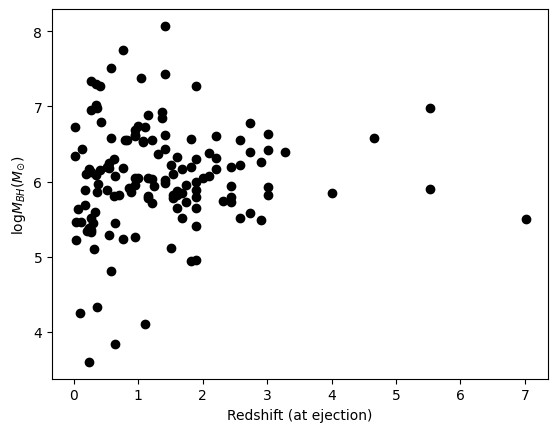

In [ ]:
## ANALYZE GALAXIES WITH REFILLED BHs
    # data = snap : galaxies, volume, metadata
    # ie: data[2][0] = snapshot 2, galaxies

# w = data[10][0].BHEjectedTime > 0
# print(data[10][0].BHEjectedTime[w])


eject_times = []
refill_times = []
stellar_masses_ejected = []
stellar_masses_refilled = []
bh_masses_ejected = []
bh_masses_refilled = []
merge_types = []
for snap in range(1, 100):
    galaxies = data[snap][0]
    metadata = data[snap][2]
    array_length = len(galaxies)

    if array_length > 0:
        
        for i in range(array_length):
            if galaxies.BHEjectedTime[i] > 0:
                eject_time = galaxies.BHEjectedTime[i]
                redshift = metadata['redshift']
                tot_ejections = galaxies.BHejectCount[i]
                # print(eject_time, redshift)
                # snap_num = snap - 1 # gal information stored in 
                # print("A BH was ejected for this snapshot:", snap_num, "At time:", eject_time)

                stellar_mass_ejected = np.log10(galaxies.StellarMass[i] * 1e10 / hubble_h)
                bh_mass_ejected = np.log10(galaxies.MassofLastEjectedBH[i] * 1e10 / hubble_h)

                stellar_masses_ejected.append(stellar_mass_ejected)
                bh_masses_ejected.append(bh_mass_ejected)
                eject_times.append(redshift)

            if galaxies.BHRefilledTime[i] > 0:
                refill_time = galaxies.BHRefilledTime[i]
                redshift = metadata['redshift']
                tot_refills = galaxies.BHrefillCount[i]

                stellar_mass_refilled = np.log10(galaxies.StellarMass[i] * 1e10 / hubble_h)
                bh_mass_refilled = np.log10(galaxies.MassofLastEjectedBH[i] * 1e10 / hubble_h)

                stellar_masses_refilled.append(stellar_mass_refilled)
                bh_masses_refilled.append(bh_mass_refilled)
                refill_times.append(redshift)


                



plt.scatter(eject_times, bh_masses_ejected, marker='o', color='black')
plt.scatter(refill_times, bh_masses_refilled, marker='o', color='black')
plt.xlabel('Redshift (at ejection)')
plt.ylabel(r'log$_{10}M_{BH}(M_{\odot})$')
plt.scatter()
plt.show()



/Users/pater32/Documents/GitHub/sage/GWRecoil/sage_venv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


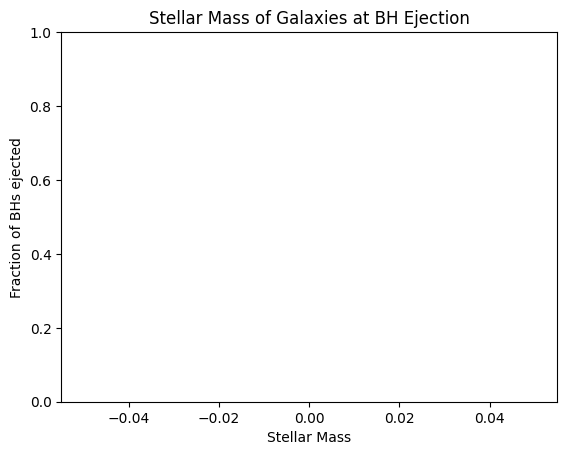

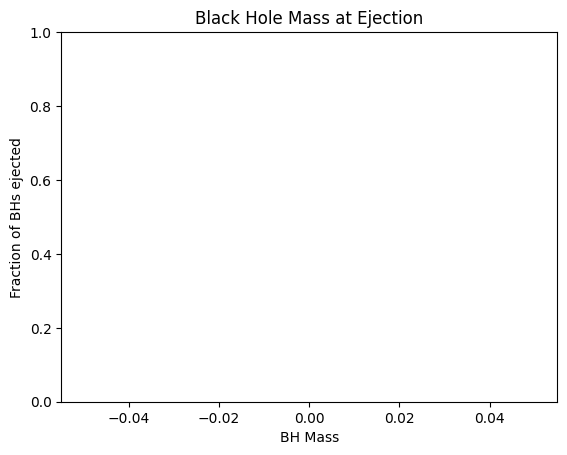

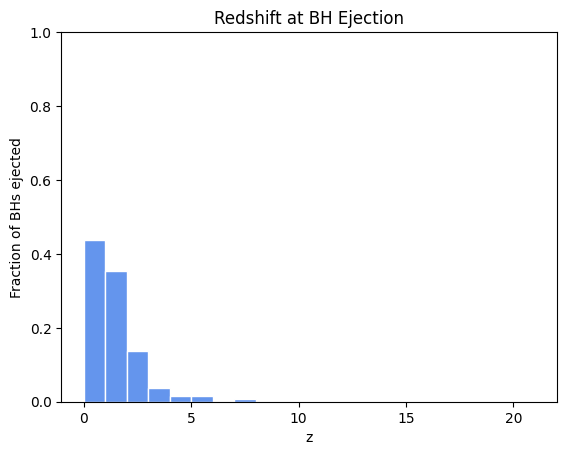

In [24]:
## MAKE HISTOGRAMS FOR GALAXIES 

# GALAXY SM HISTOGRAM (WHEN WERE THESE BLACK HOLES EJECTED)
min_sm = 7.0
max_sm = 12.0
interval = 0.5
n_bins = int((max_sm-min_sm)/interval)
hist, edges_sm = np.histogram(stellar_mass, range = (min_sm, max_sm), bins = n_bins)
plt.hist(stellar_masses, bins=edges_sm, density = True, color = 'cornflowerblue', edgecolor='white')
plt.xlabel('Stellar Mass')
plt.ylabel('Fraction of BHs ejected')
plt.title('Stellar Mass of Galaxies at BH Ejection')
plt.ylim(0, 1)
plt.show()

# BLACK HOLE MASS AT EJECTION 
min_bh = 3.0
max_bh = 8.0
interval = 0.5
n_bins = int((max_bh-min_bh)/interval)
hist, edges_bh = np.histogram(bh_mass, range = (min_bh, max_bh), bins = n_bins)
plt.hist(bh_masses, bins=edges_bh, density = True, color = 'cornflowerblue', edgecolor='white')
plt.xlabel('BH Mass')
plt.ylabel('Fraction of BHs ejected')
plt.title('Black Hole Mass at Ejection')
plt.ylim(0, 1)
plt.show()

min_z = 0
max_z = 21.0
interval = 1
n_bins = int((max_z-min_z)/interval)
hist, edges_z = np.histogram(eject_times, range = (min_z, max_z), bins = n_bins)
plt.hist(eject_times, bins=edges_z, density = True, color = 'cornflowerblue', edgecolor='white')
plt.xlabel('z')
plt.ylabel('Fraction of BHs ejected')
plt.title('Redshift at BH Ejection')
plt.ylim(0, 1)
plt.show()

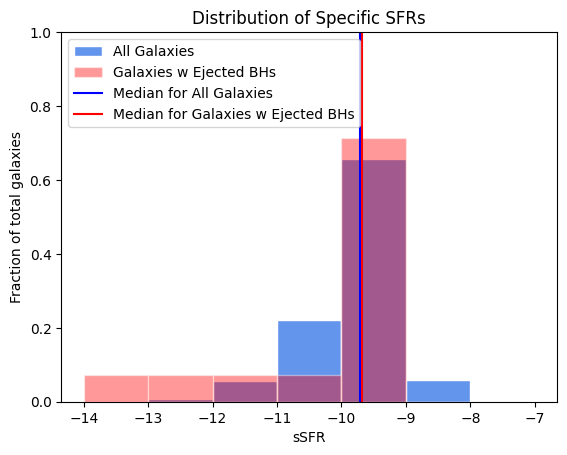

2554
-9.707121
14
-9.686593
12
-9.635028


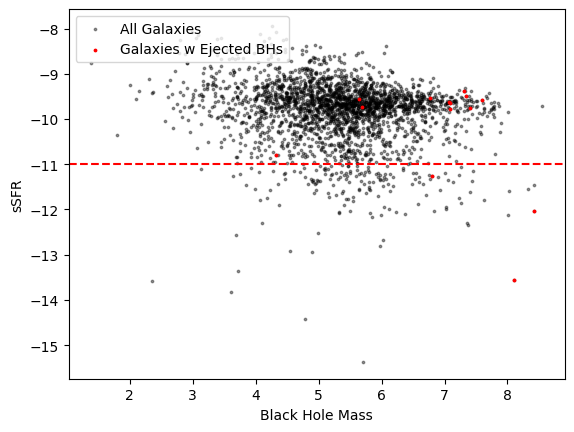

In [25]:
## STELLAR POPULATIONS OF ALL GALAXIES VS GALAXIES W/ REFILLED BLACK HOLES

all_ssfrs = []
all_bhs = []

ejected_ssfrs = []
ejected_bhs = []

refilled_ssfrs = []



galaxies = data[63][0]
metadata = data[63][2]
array_length = len(galaxies)

for i in range(array_length):
    sfr = galaxies.SfrDisk[i] + galaxies.SfrBulge[i]
    bh_mass_sim = galaxies.BlackHoleMass[i]

    if (sfr > 0) & (bh_mass_sim > 0):
        stellar_mass = galaxies.StellarMass[i] * 1e10 / hubble_h
        sSFR = np.log10(sfr/stellar_mass)
        bh_mass = np.log10(bh_mass_sim * 1e10 / hubble_h)
        all_ssfrs.append(sSFR)
        all_bhs.append(bh_mass)

        if galaxies.BHejectCount[i] > 0:
            ejected_ssfrs.append(sSFR)
            ejected_bhs.append(bh_mass)
        
        if galaxies.BHrefillCount[i] > 0:
            refilled_ssfrs.append(sSFR)

min_z = -14
max_z = -7
interval = 1
n_bins = int((max_z-min_z)/interval)
hist, edges = np.histogram(all_ssfrs, range = (min_z, max_z), bins = n_bins)
plt.hist(all_ssfrs, bins=edges, density = True, color = 'cornflowerblue', edgecolor='white', label='All Galaxies')
plt.hist(ejected_ssfrs, bins=edges, density = True, color = 'red', alpha=.4, edgecolor='white', label='Galaxies w Ejected BHs')
# plt.hist(refilled_ssfrs, bins=edges, density = True, color = 'red', alpha=.4, edgecolor='white', label='Galaxies w Refilled BHs')
plt.axvline(np.median(all_ssfrs), color = 'blue', label = 'Median for All Galaxies')
plt.axvline(np.median(ejected_ssfrs), color = 'red', label = 'Median for Galaxies w Ejected BHs')
# plt.axvline(np.median(refilled_ssfrs), color = 'red', label = 'Median for Galaxies w Refilled BHs')
plt.xlabel('sSFR')
plt.ylabel('Fraction of total galaxies')
plt.title('Distribution of Specific SFRs')
plt.legend(loc='upper left')
plt.ylim(0, 1)
plt.show()


print(len(all_ssfrs))
print(np.median(all_ssfrs))
print(len(ejected_ssfrs))
print(np.median(ejected_ssfrs))
print(len(refilled_ssfrs))
print(np.median(refilled_ssfrs))

plt.scatter(all_bhs, all_ssfrs, color = 'black', marker='o', alpha=.4, s=3, label='All Galaxies')
plt.scatter(ejected_bhs, ejected_ssfrs, color = 'red', marker='o', s=3, label='Galaxies w Ejected BHs')
plt.axhline(-11, linestyle='dashed', color='red')
plt.xlabel('Black Hole Mass')
plt.ylabel('sSFR')
plt.legend(loc='upper left')




(0.0, 1.0)

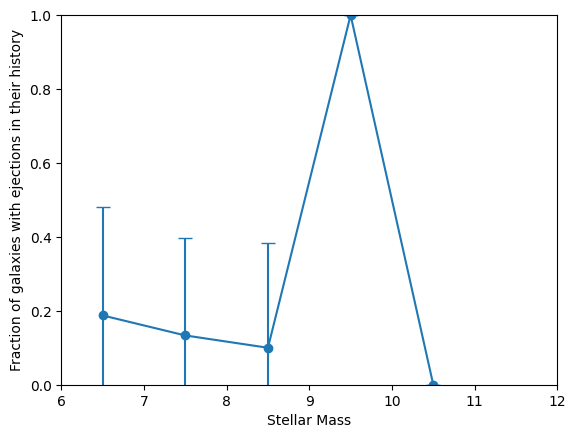

In [26]:
## EJECTION FRACTION PLOT WITH ERROR BARS
def safe_div(numerator, denominator):
        if denominator > 0:
            return numerator / denominator
        else:
            return 0.0

eject_mask = (galaxies.StellarMass > 0) & (galaxies.BHejectCount > 0)
stellar_mass = galaxies.StellarMass
stellar_mass_eject = galaxies.StellarMass[eject_mask]


min_range = 6
max_range = 12
interval = 1
nbins = int((max_range - min_range) / interval)
mass_bins = np.arange(min_range, max_range, interval)


mass = []  # Bin centers
bh_eject_fraction = []
errors = []
for i in range(nbins - 1):
        # All galaxies in this mass bin
        this_bin_mask = (stellar_mass >= mass_bins[i]) & (stellar_mass < mass_bins[i + 1])
        this_bin_count = np.sum(this_bin_mask)

        # Galaxies that have had ejected black holes in this mass been
        bh_eject_mask = (stellar_mass_eject >= mass_bins[i]) & (stellar_mass_eject < mass_bins[i + 1])
        bh_eject_count = np.sum(bh_eject_mask)

        #Calculate occupation fraction
        bh_eject_fraction.append(safe_div(bh_eject_count, this_bin_count))

        # Standard deviation (binomial) for ejection fraction
        bh_eject_frac = safe_div(bh_eject_count, this_bin_count)
        sigma = np.sqrt(safe_div(bh_eject_frac*(1-bh_eject_frac), this_bin_count))
        errors.append(3*sigma)
        

        # Store the mass bin center
        mass.append((mass_bins[i] + mass_bins[i + 1]) / 2.0)

plt.errorbar(mass, bh_eject_fraction, marker='o', yerr=errors, capsize=5)
plt.xlabel('Stellar Mass')
plt.ylabel('Fraction of galaxies with ejections in their history')
plt.xlim(min_range, max_range)
plt.ylim(0, 1)